In [1]:
import pandas as pd
from src.visualization import plot_galaxy
from src.feature_engineering import load_fits, feature_engineering_pipeline

In [2]:
# Para obtener los ID de las galaxias anillo
# Cargamos el catálogo de clasificación
# y lo filramos para quedarnos solo con las galaxias anillo (label == 1)
classification_catalogue_df = pd.read_csv("../data/raw/catalogs/classification_dataset.csv")
rings_df = classification_catalogue_df[classification_catalogue_df["label"] == 1].reset_index(drop=True).drop(columns=["anillos", "source"])
rings_df.head()

,name,objra,objdec,nsa_z,label
0,1237652946379079804,2.142880,-10.949290,0.030352,1
1,1237663783662256198,3.992692,-0.303504,0.039373,1
2,1237672796109144083,4.074376,-9.134164,0.036546,1
3,1237652946917523563,5.761652,-10.554394,0.041292,1
4,1237679436131729553,6.079566,-1.638201,0.037724,1


# Visualizar el pipeline de ingenieria de caracteristicas en muchas imágenes

In [14]:
# Seleccionamos N < df.shape[0] galaxias anillo al azar para visualizarlas
N = 10
sampled_rings_df = rings_df.sample(n=N, random_state=42).reset_index(drop=True)
sampled_rings_df.head()

,name,objra,objdec,nsa_z,label
0,manga-9877-9102,194.340601,27.880430,0.024809,1
1,manga-12081-6102,31.719986,-0.518100,0.043344,1
2,1237667429034426523,175.969480,26.203068,0.031100,1
3,1237667730730647698,121.088790,10.103044,0.034238,1
4,1237657856064487433,150.870070,46.628347,0.016101,1


# Ejemplo de una visualización bandas originales contra bandas después de la ingenieria de caracteristicas

In [15]:
def compare_original_vs_engineered_bands(galaxy_id, galaxy_label, parent_folder_path="../data/raw/legacy_fits_files/"):
    """
    Muestra la comparación de bandas originales v.s. bandas después de la ingeniería de características
    para una galaxia.
    """
    original_images = load_fits(
        galaxy_id=galaxy_id,
        label=galaxy_label,
        parent_folder_path=parent_folder_path
    )
    plot_galaxy(galaxy_id, original_images)

    engineered_images = {
        band: feature_engineering_pipeline(img)
        for band, img in original_images.items()
    }
    plot_galaxy(galaxy_id, engineered_images)

    return None

In [16]:
a_galaxy_id = sampled_rings_df.loc[0, "name"]
a_galaxy_label = sampled_rings_df.loc[0, "label"]

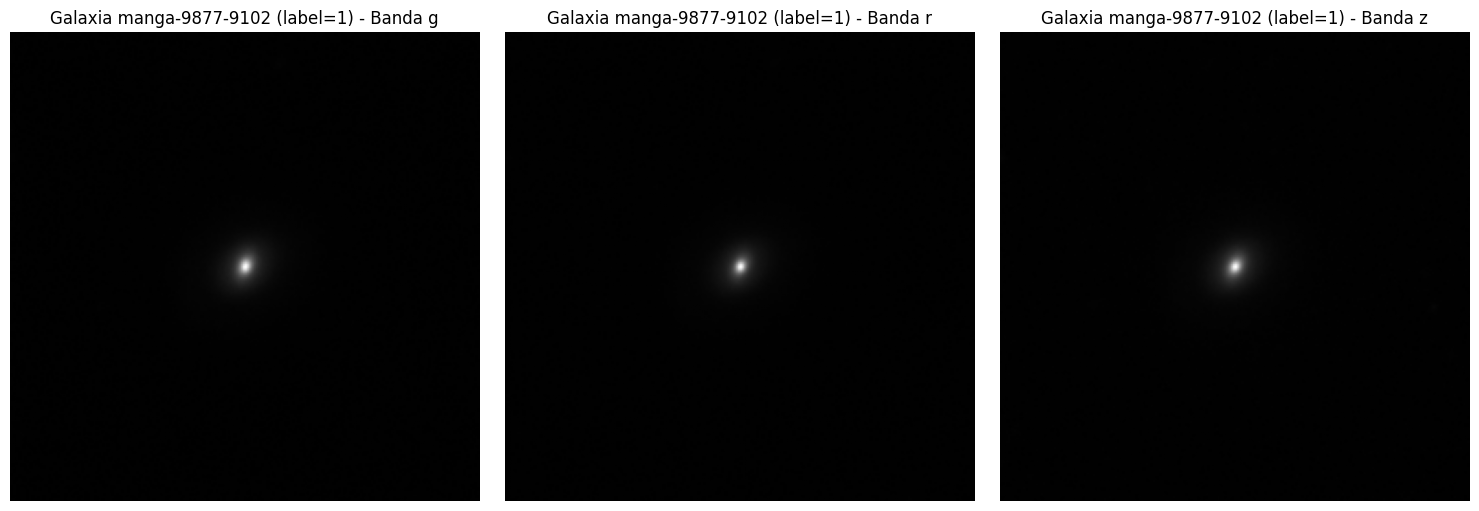

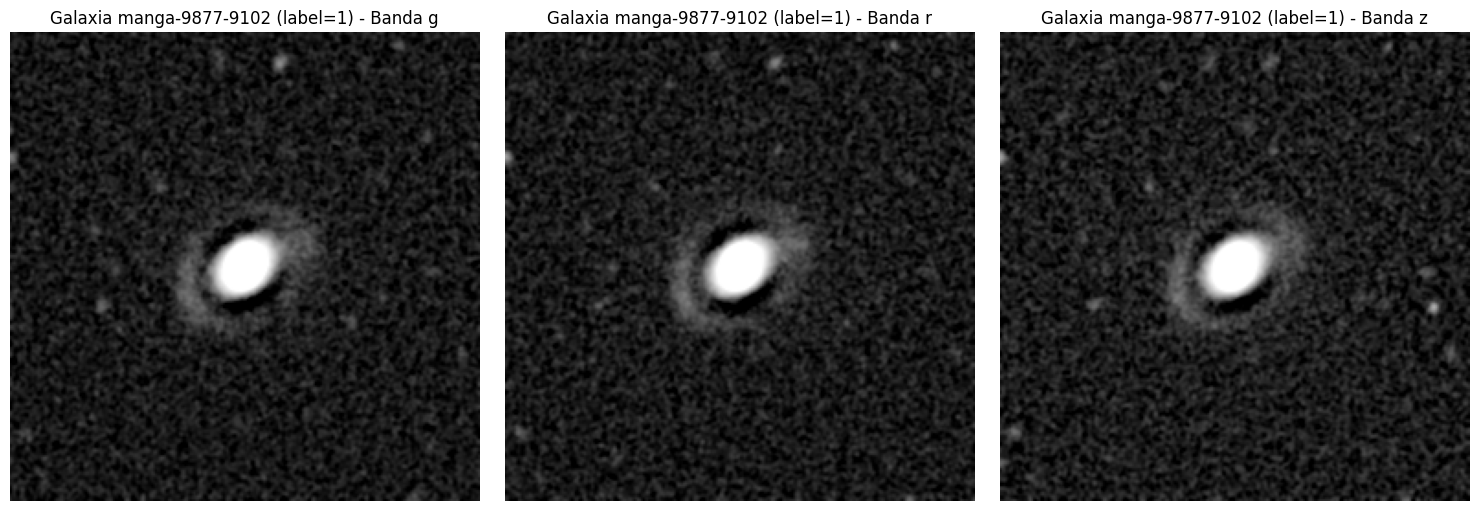

In [17]:
compare_original_vs_engineered_bands(
    galaxy_id=a_galaxy_id,
    galaxy_label=a_galaxy_label,
)

# Ver la N visualizaciones

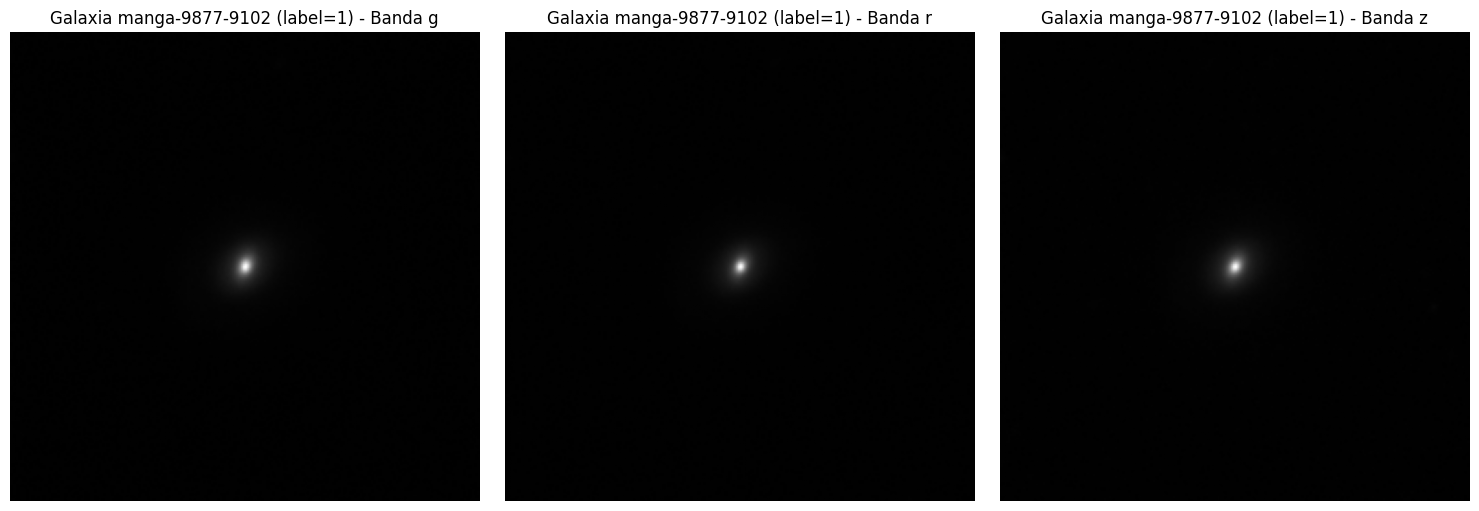

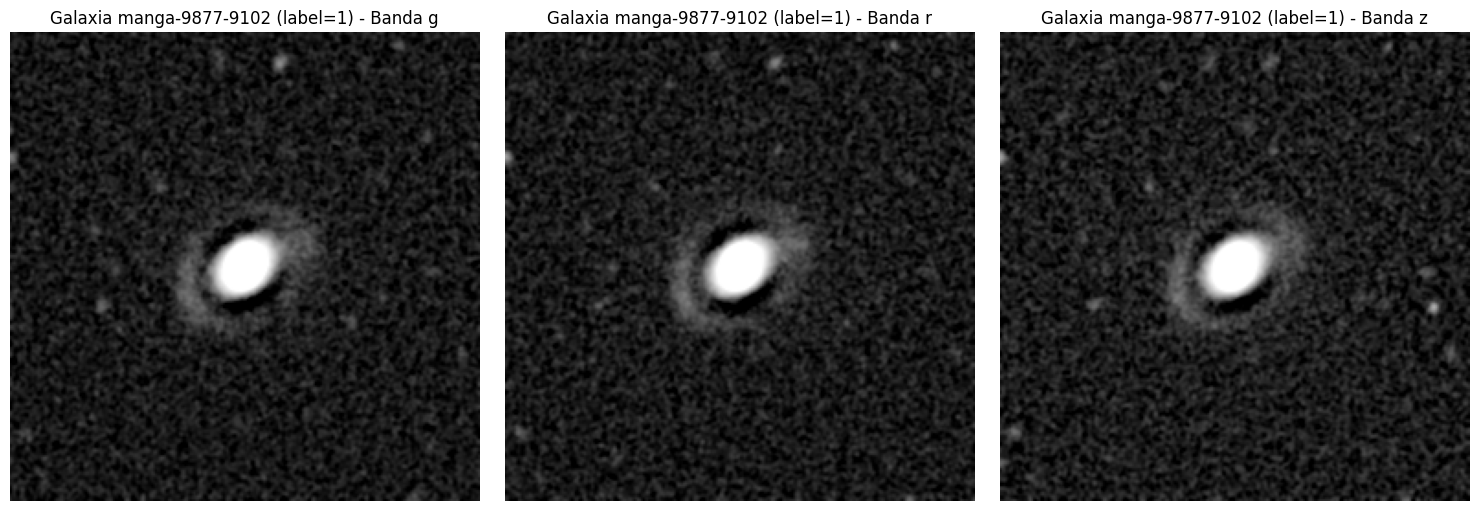

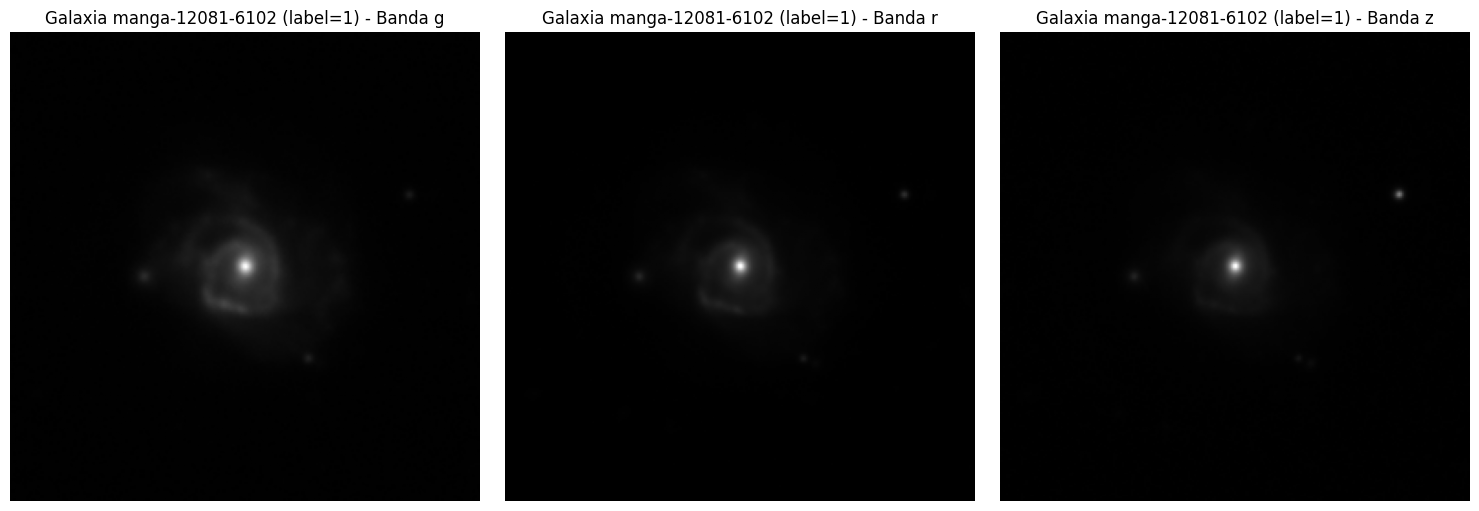

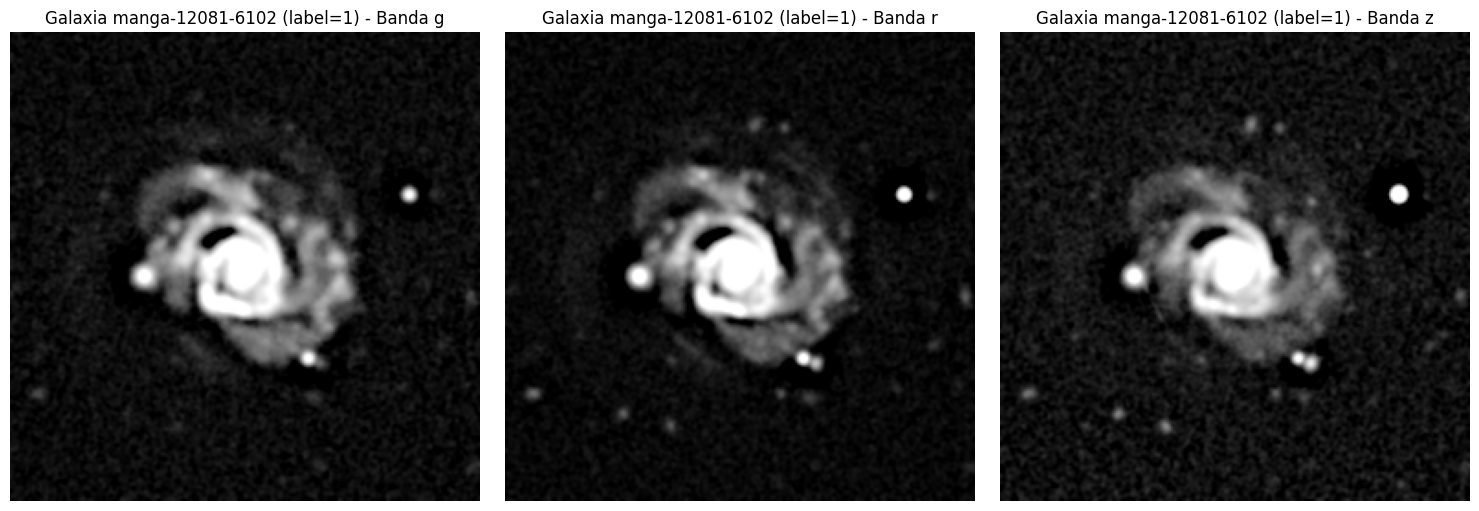

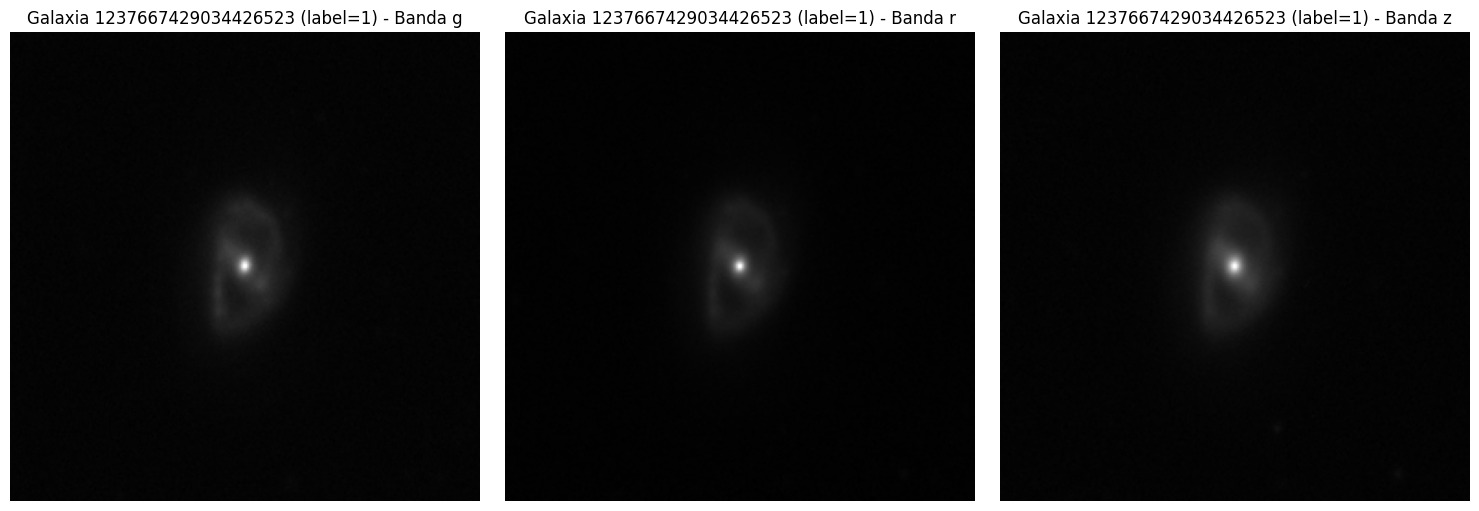

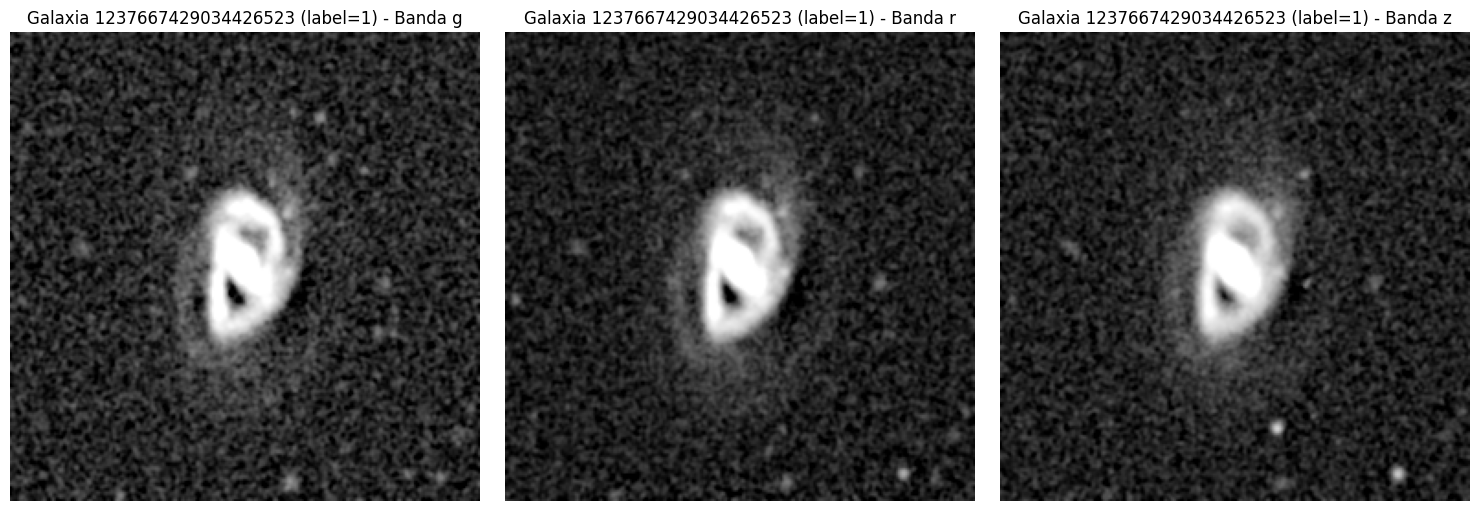

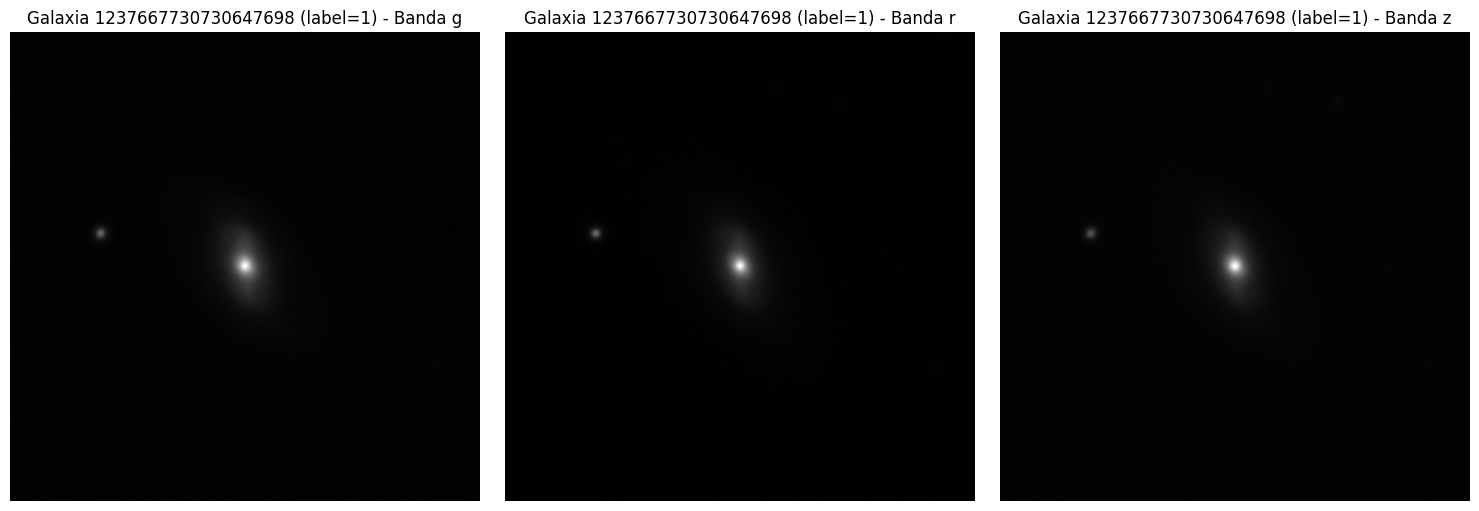

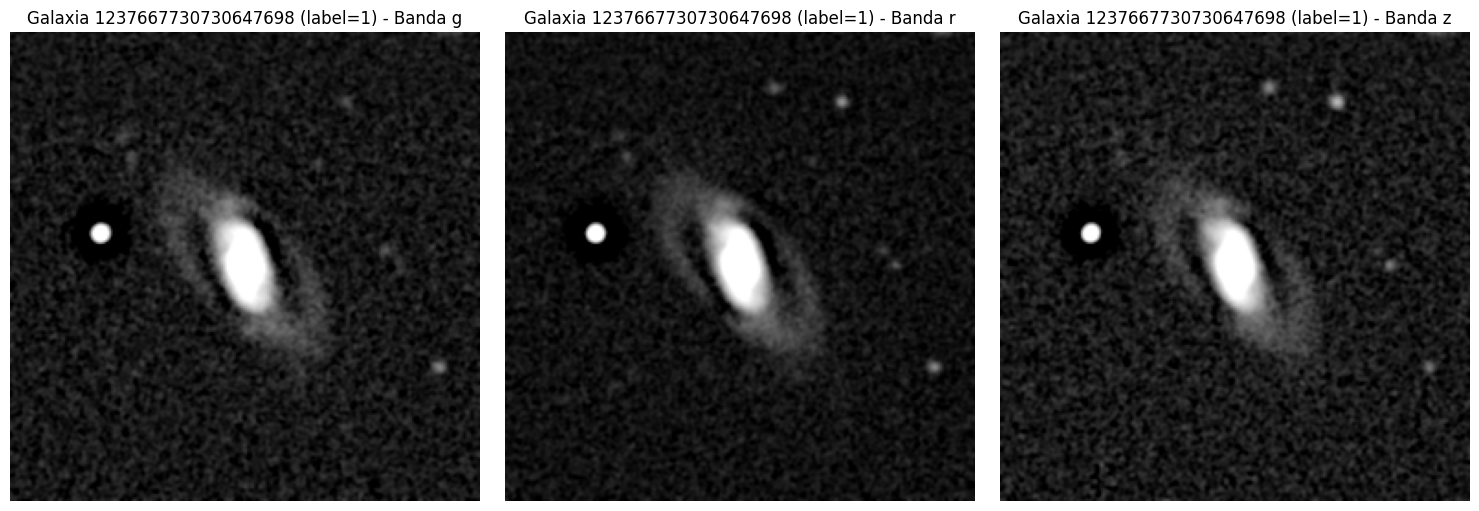

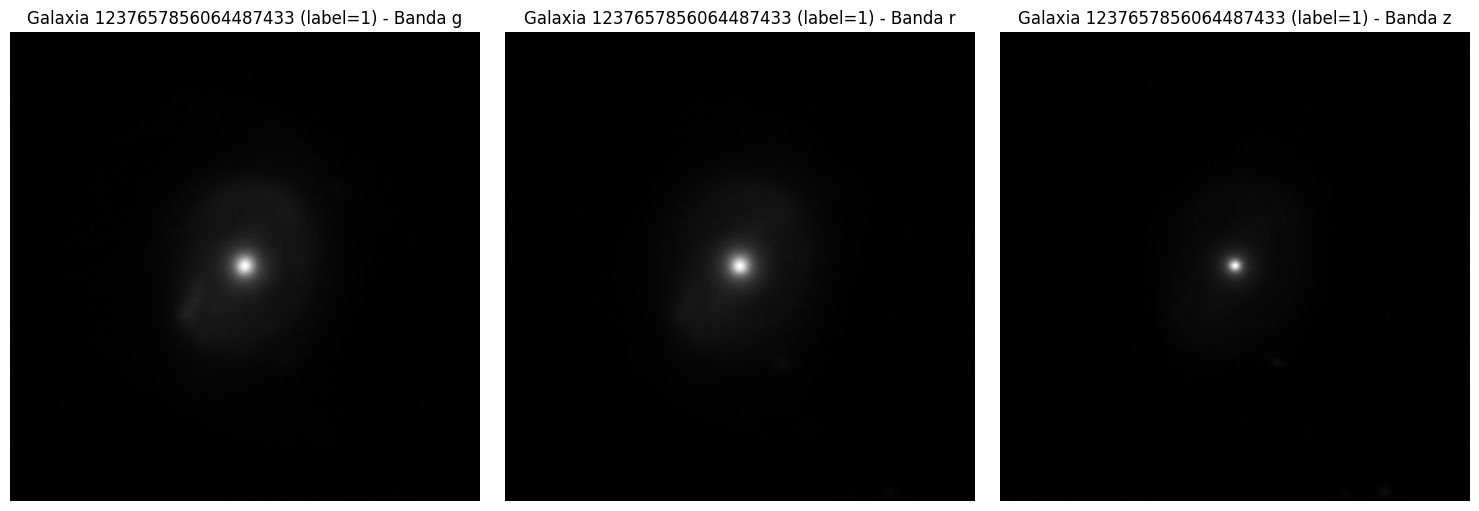

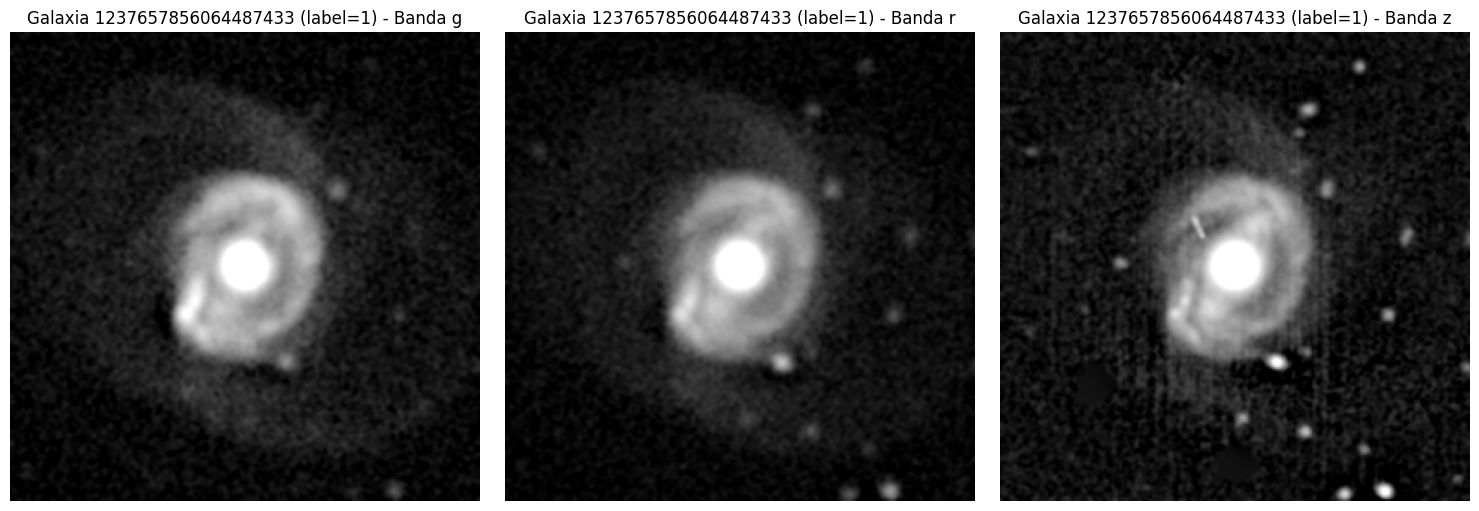

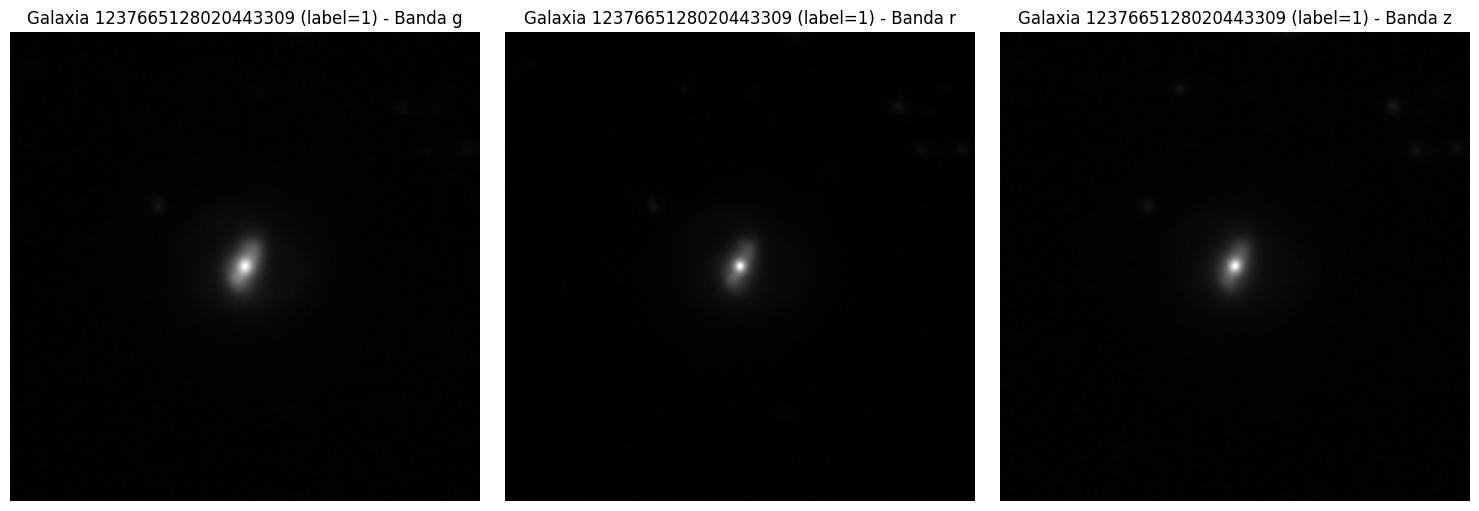

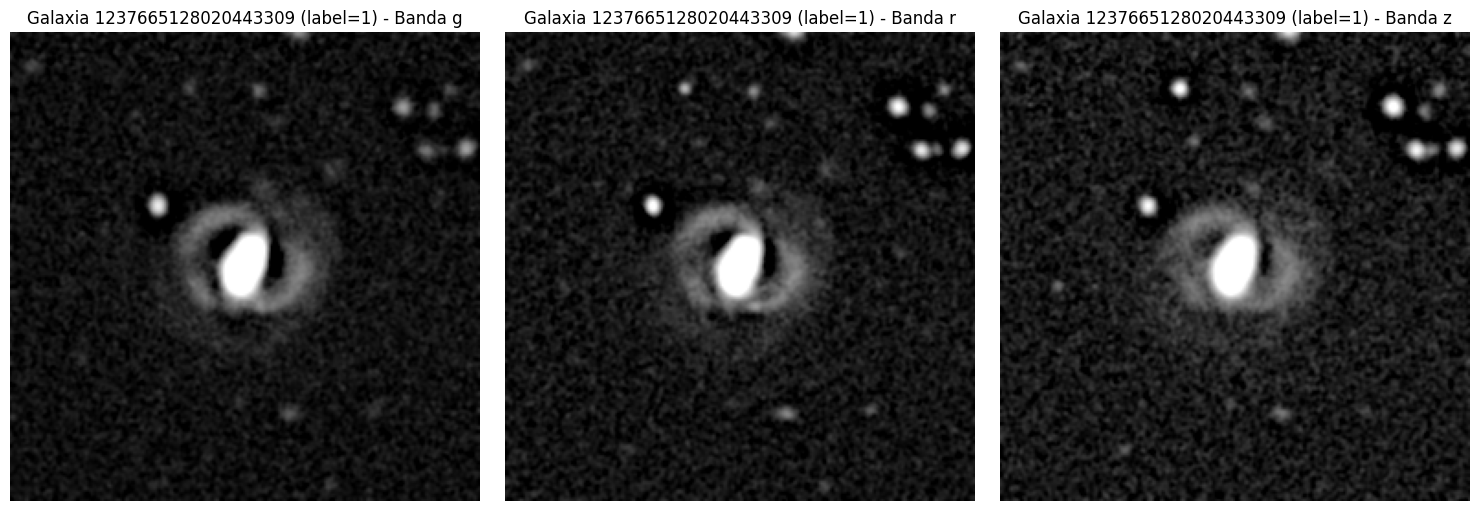

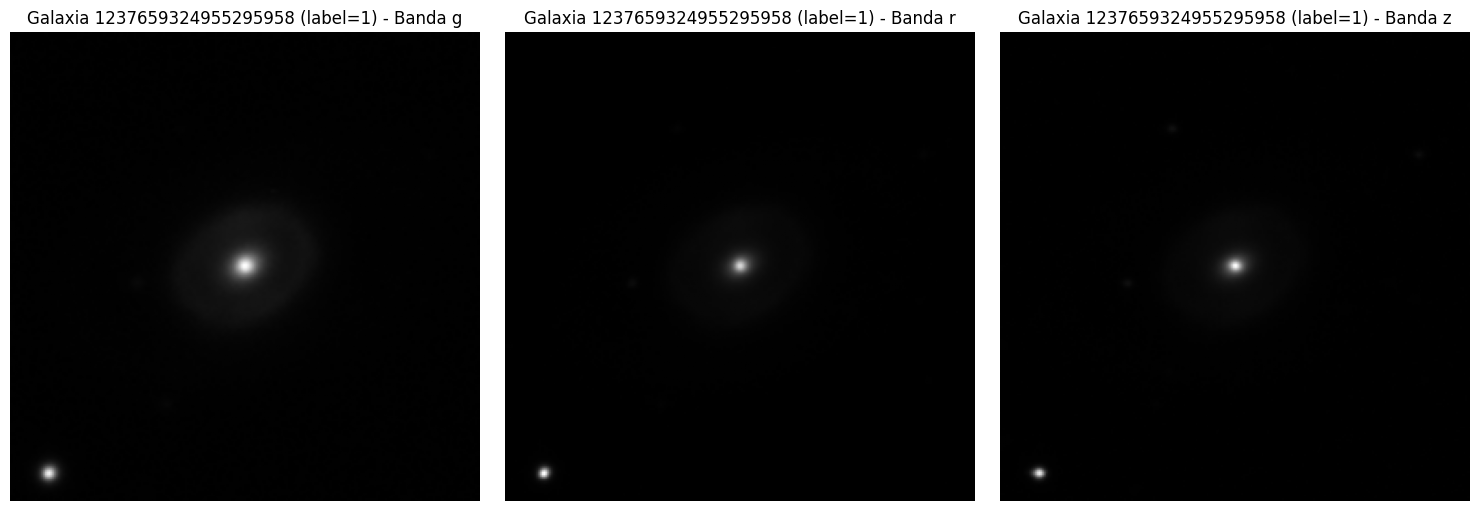

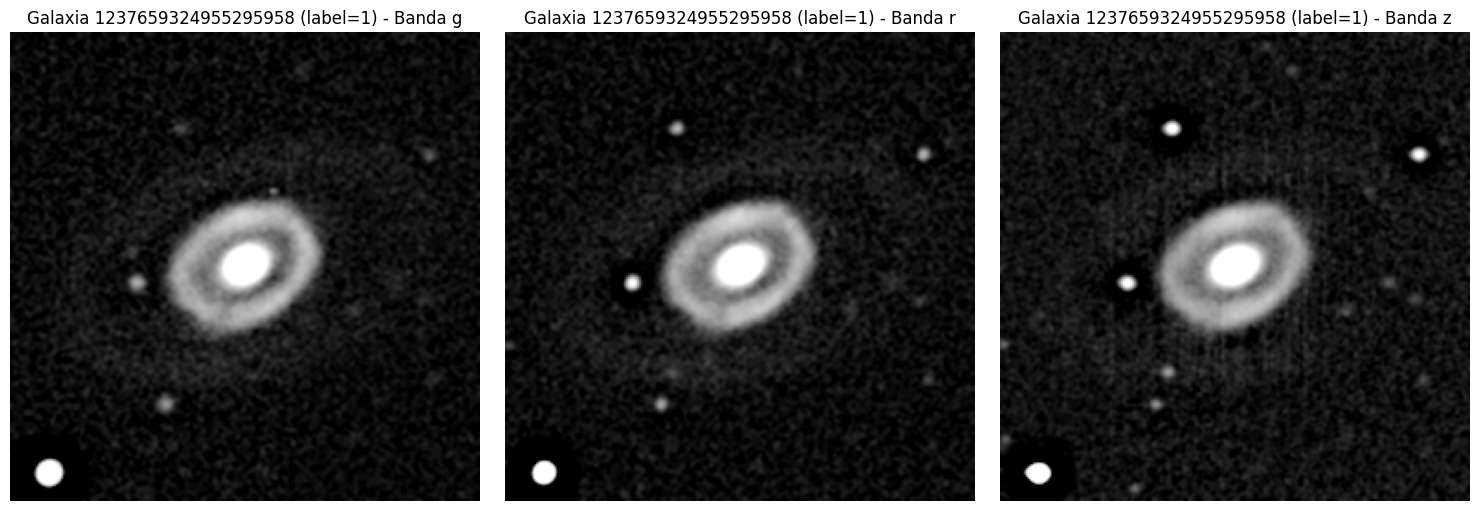

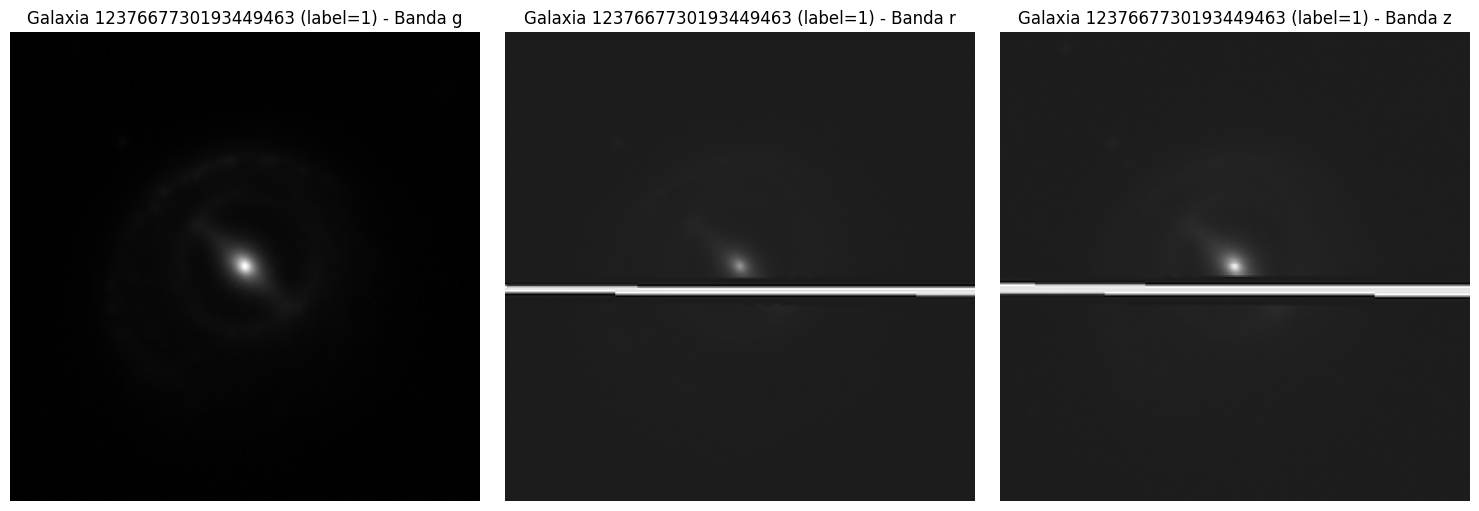

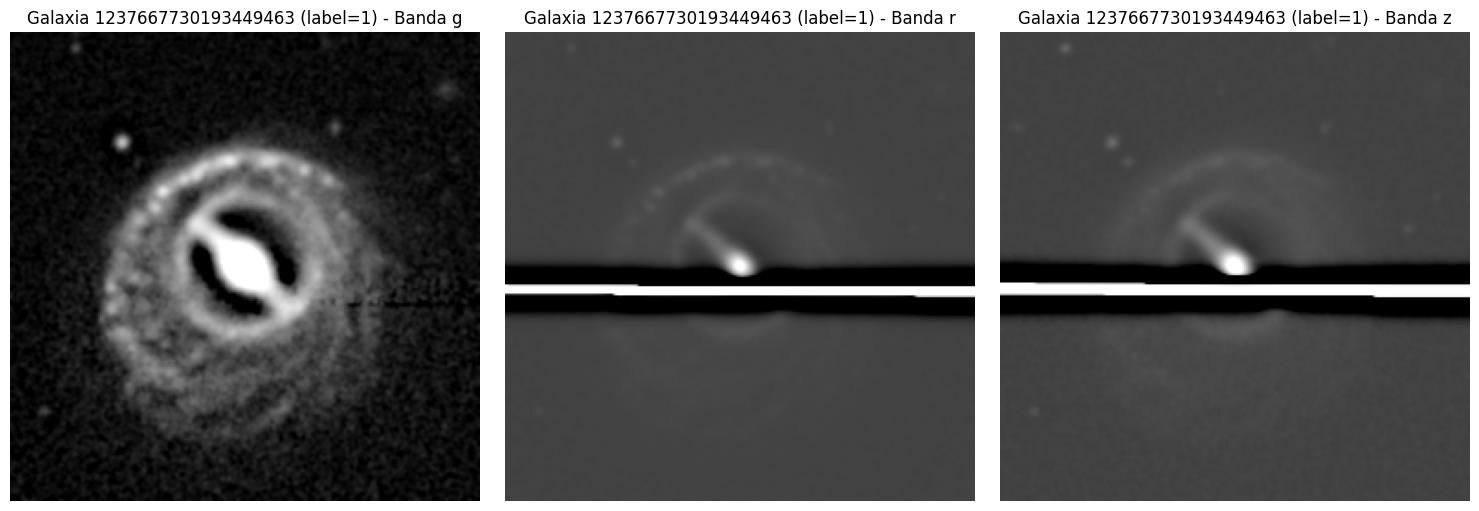

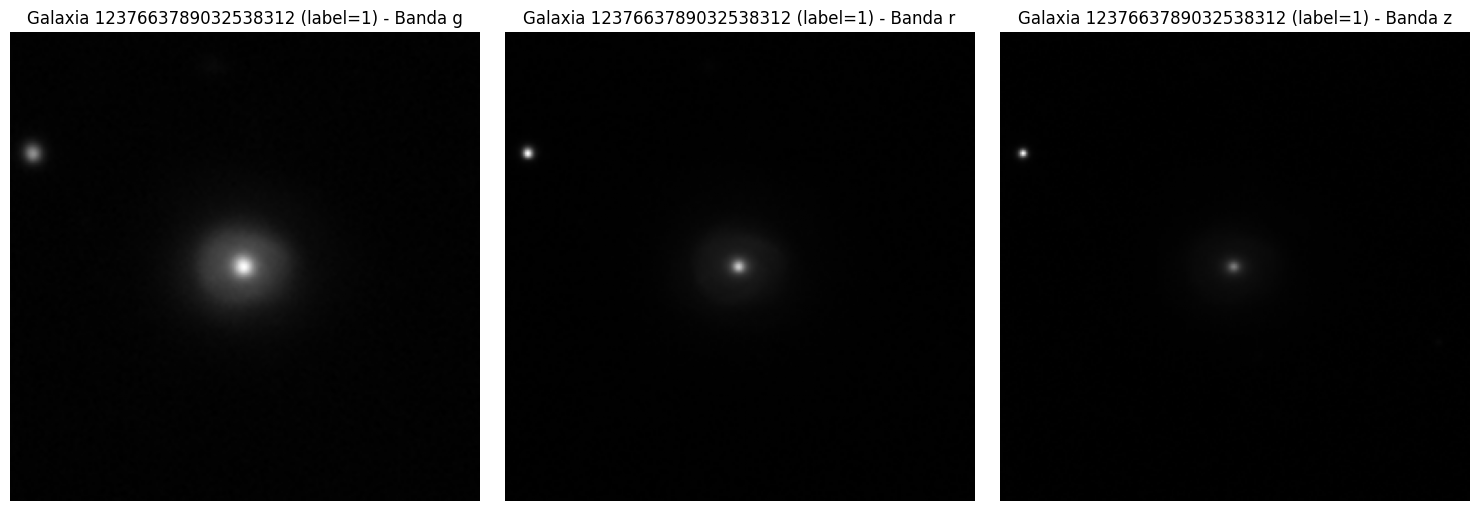

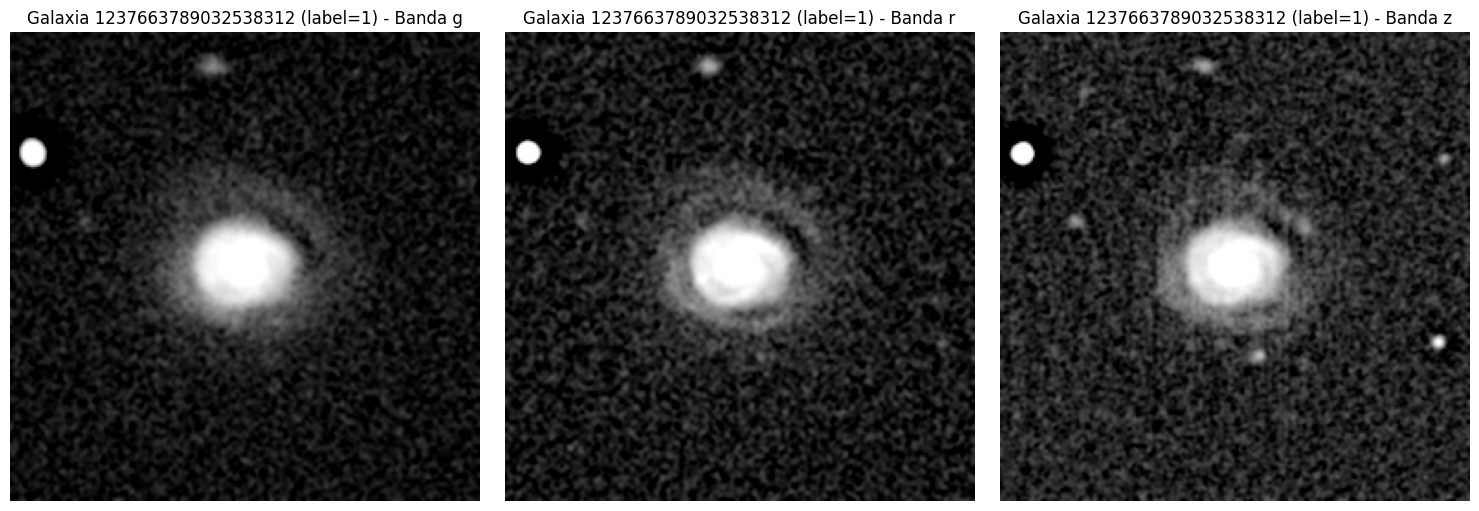

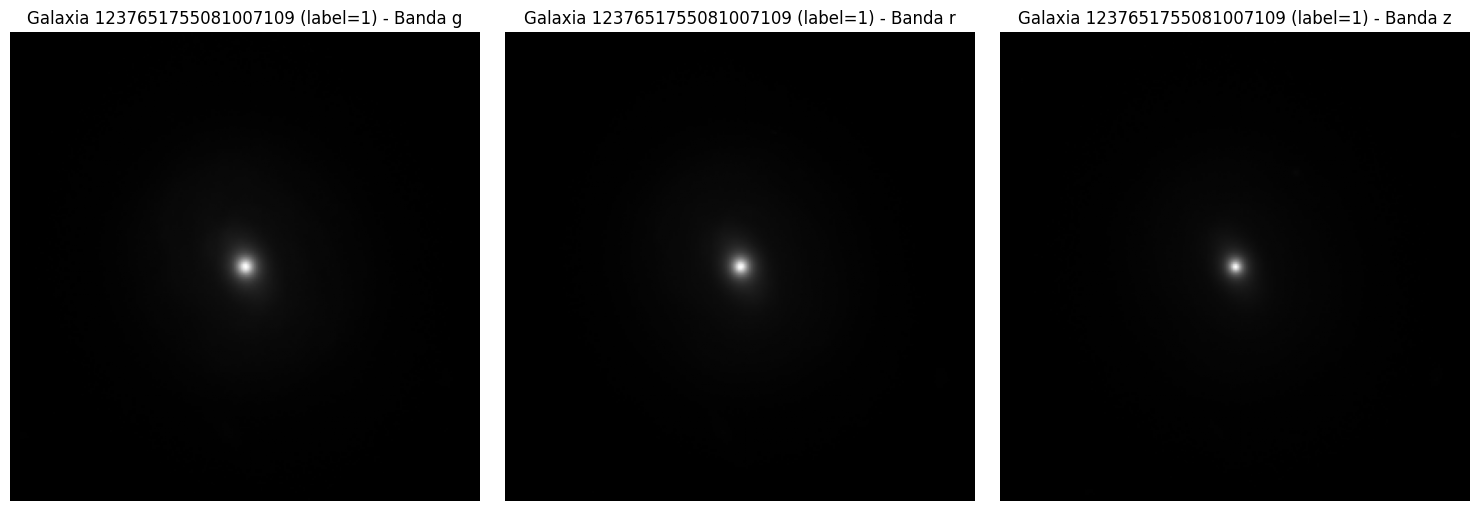

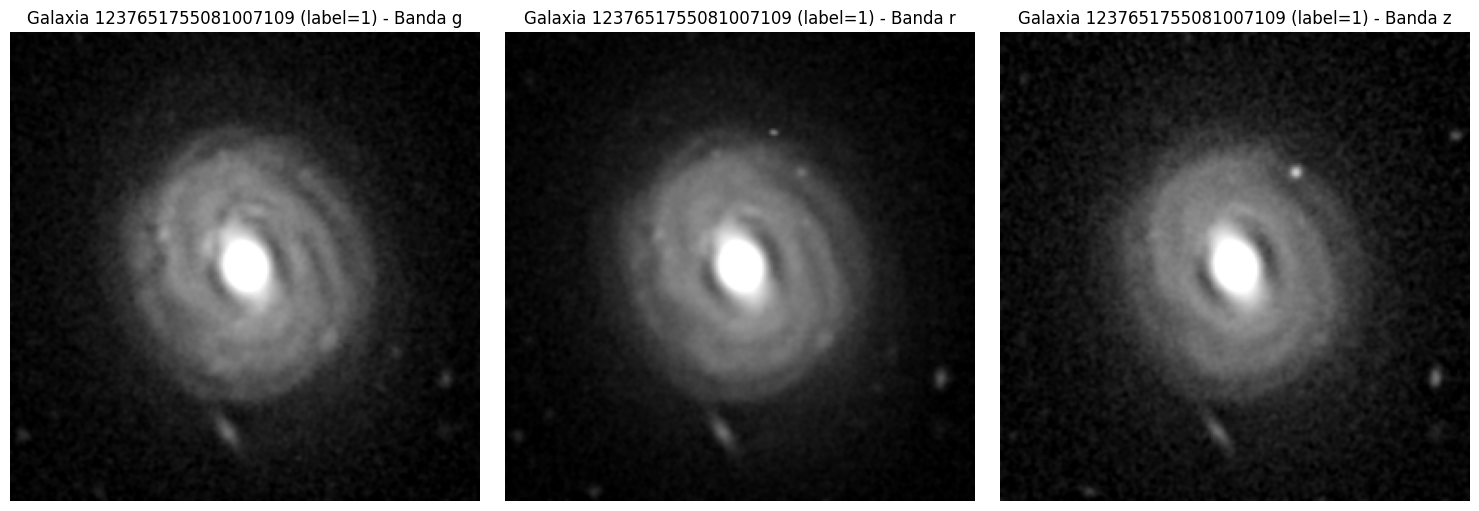

In [18]:
# Visualizamos todas las galaxias anillo seleccionadas
for idx in range(N):
    a_galaxy_id = sampled_rings_df.loc[idx, "name"]
    a_galaxy_label = sampled_rings_df.loc[idx, "label"]

    compare_original_vs_engineered_bands(
        galaxy_id=a_galaxy_id,
        galaxy_label=a_galaxy_label,
    )

# 